# 03 · Kernel PCA and manifold learning on the Swiss roll

**Questions:**
1. Can Kernel PCA unroll a curved manifold?
2. How do we pick its kernel and γ? The book proposes two rules (pp. 229-232): the best downstream accuracy (`GridSearchCV`), or the lowest reconstruction pre-image error (unsupervised).
3. How do LLE, Isomap, MDS and t-SNE compare (Fig. 8-13)?

The book fits everything on all 1,000 points. Here 25% of the roll is held out: both rules choose using the other 75% only (the unsupervised rule by 3-fold cross-validation of the pre-image error), and both choices are then judged on the held-out points.

In [1]:
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from dimred_mlops.config import load_config
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 20)
CFG = load_config(ROOT / "configs/full_flow_config.yaml")
SEED = CFG["seed"]
# figures are drawn into a temporary folder: reports/figures belongs to the pipeline run
import tempfile
FIG = Path(tempfile.mkdtemp(prefix="nb-figures-"))

In [2]:
from dimred_mlops.data import swiss_roll
X, t, y = swiss_roll(1000, 0.2, SEED)     # y = 1 where the position along the roll t > 6.9
X.shape, y.mean().round(3)

((1000, 3), np.float64(0.751))

## 1. The book's grid search: kPCA → Logistic Regression, 2 kernels × 10 values of γ = 20 settings

In [3]:
from sklearn.model_selection import GridSearchCV, train_test_split
from dimred_mlops.manifold import kpca_pipeline
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
param_grid = [{"kpca__gamma": np.linspace(0.03, 0.05, 10), "kpca__kernel": ["rbf", "sigmoid"]}]
grid_search = GridSearchCV(kpca_pipeline(SEED), param_grid, cv=3)
grid_search.fit(X_tr, y_tr)
print(grid_search.best_params_, "CV accuracy", round(grid_search.best_score_, 3), "| held-out", round(grid_search.score(X_te, y_te), 3))

{'kpca__gamma': np.float64(0.04111111111111111), 'kpca__kernel': 'rbf'} CV accuracy 0.961 | held-out 0.964


## 2. The unsupervised alternative: reconstruction pre-image error (p. 231). First, reproduce the book's number

In [4]:
from sklearn.decomposition import KernelPCA
from sklearn.metrics import mean_squared_error
rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.0433, fit_inverse_transform=True, random_state=SEED)
X_reduced = rbf_pca.fit_transform(X)
X_preimage = rbf_pca.inverse_transform(X_reduced)
print("pre-image MSE:", mean_squared_error(X, X_preimage), "(the book prints 32.786308795766132)")

pre-image MSE: 32.78630879576617 (the book prints 32.786308795766132)


## 3. The full experiment (Part C of the pipeline)

In [5]:
from dimred_mlops.manifold import run_part_c
c = run_part_c(CFG["part_c"], SEED)
pd.Series(c.metrics).round(4)

best_gamma                               0.0411
best_cv_accuracy                         0.9613
best_cv_std                              0.0105
n_settings_within_one_std                7.0000
test_accuracy_supervised_choice          0.9640
test_accuracy_unsupervised_choice        0.7360
test_accuracy_raw_3d                     0.6480
test_accuracy_linear_pca_2d              0.7520
preimage_best_gamma                      0.0478
preimage_best_cv_mse                    21.7567
book_setting_preimage_mse_all_points    32.7863
n_settings                              20.0000
dtype: float64

In [6]:
c.preimage.sort_values("cv_preimage_mse").head(6).round(3)

,kernel,gamma,fit_preimage_mse,cv_preimage_mse
18,sigmoid,0.048,21.284,21.757
19,sigmoid,0.050,21.431,21.759
17,sigmoid,0.046,21.167,21.784
16,sigmoid,0.043,21.083,21.843
15,sigmoid,0.041,21.034,21.941
14,sigmoid,0.039,21.024,22.081


In [7]:
c.methods.round(3)

,method,seconds,downstream_accuracy,max_abs_corr_with_t
0,PCA,0.001,0.716,0.219
1,Kernel PCA (rbf),0.032,0.964,0.461
2,LLE,0.095,0.982,0.997
3,Isomap,0.173,0.992,0.992
4,MDS,1.863,0.751,0.179
5,t-SNE,2.168,0.987,0.904


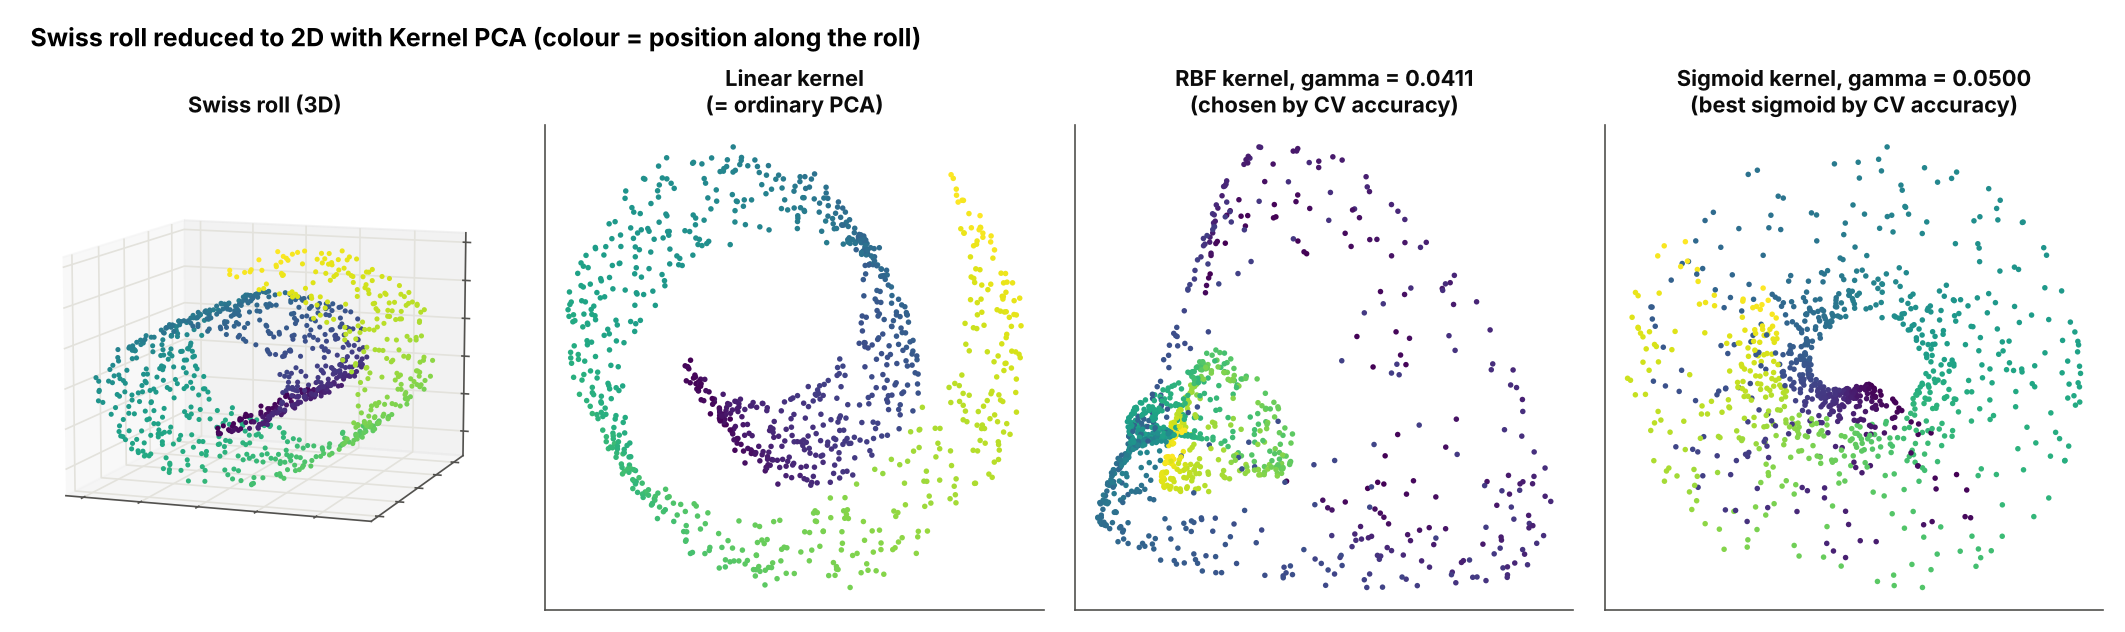

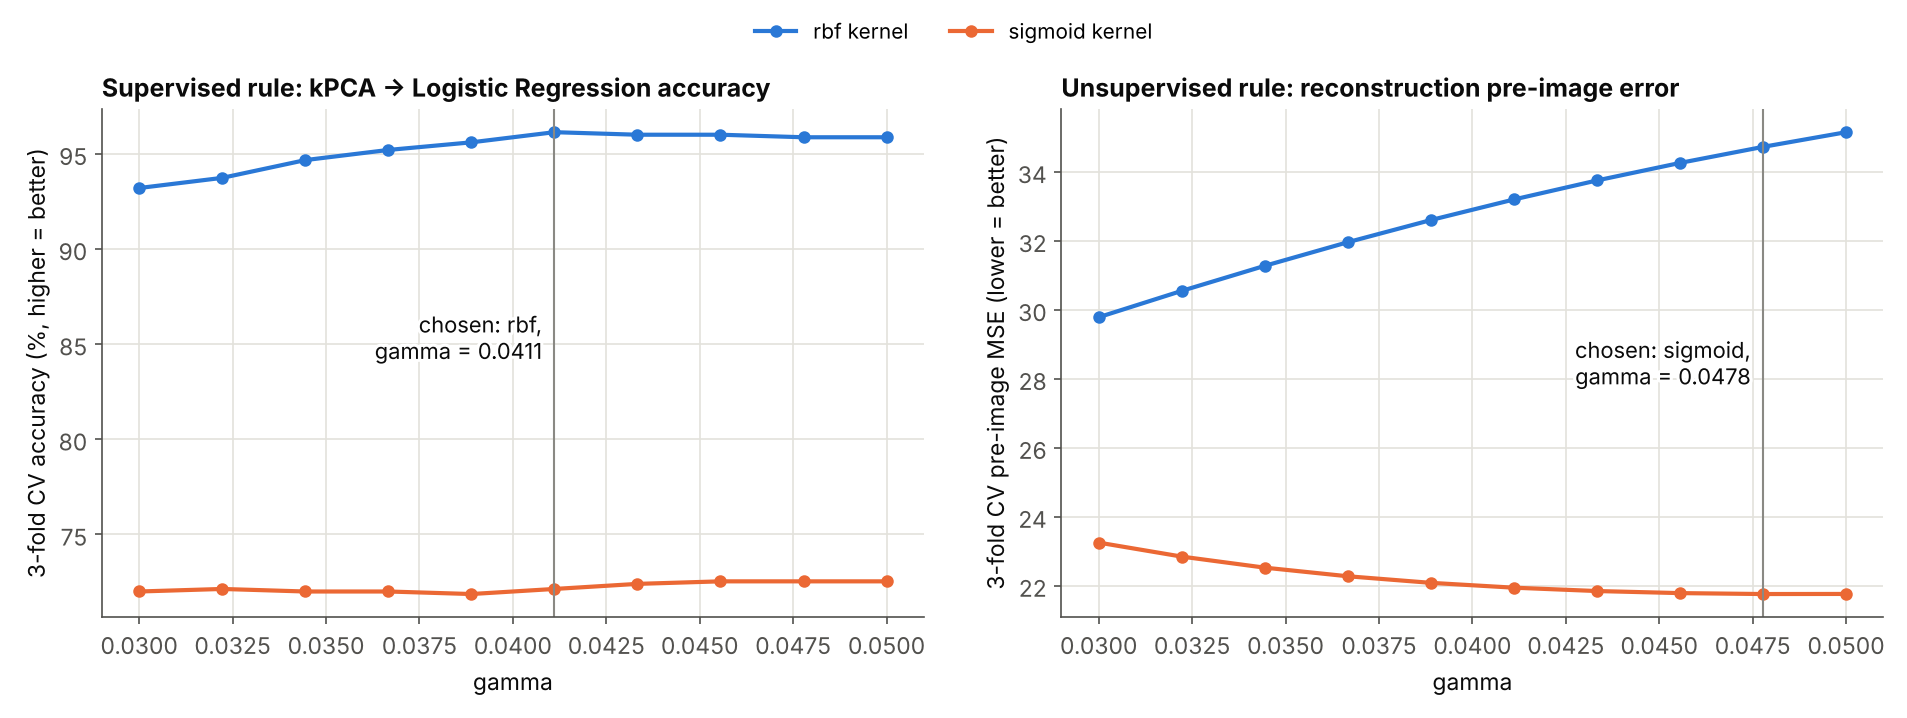

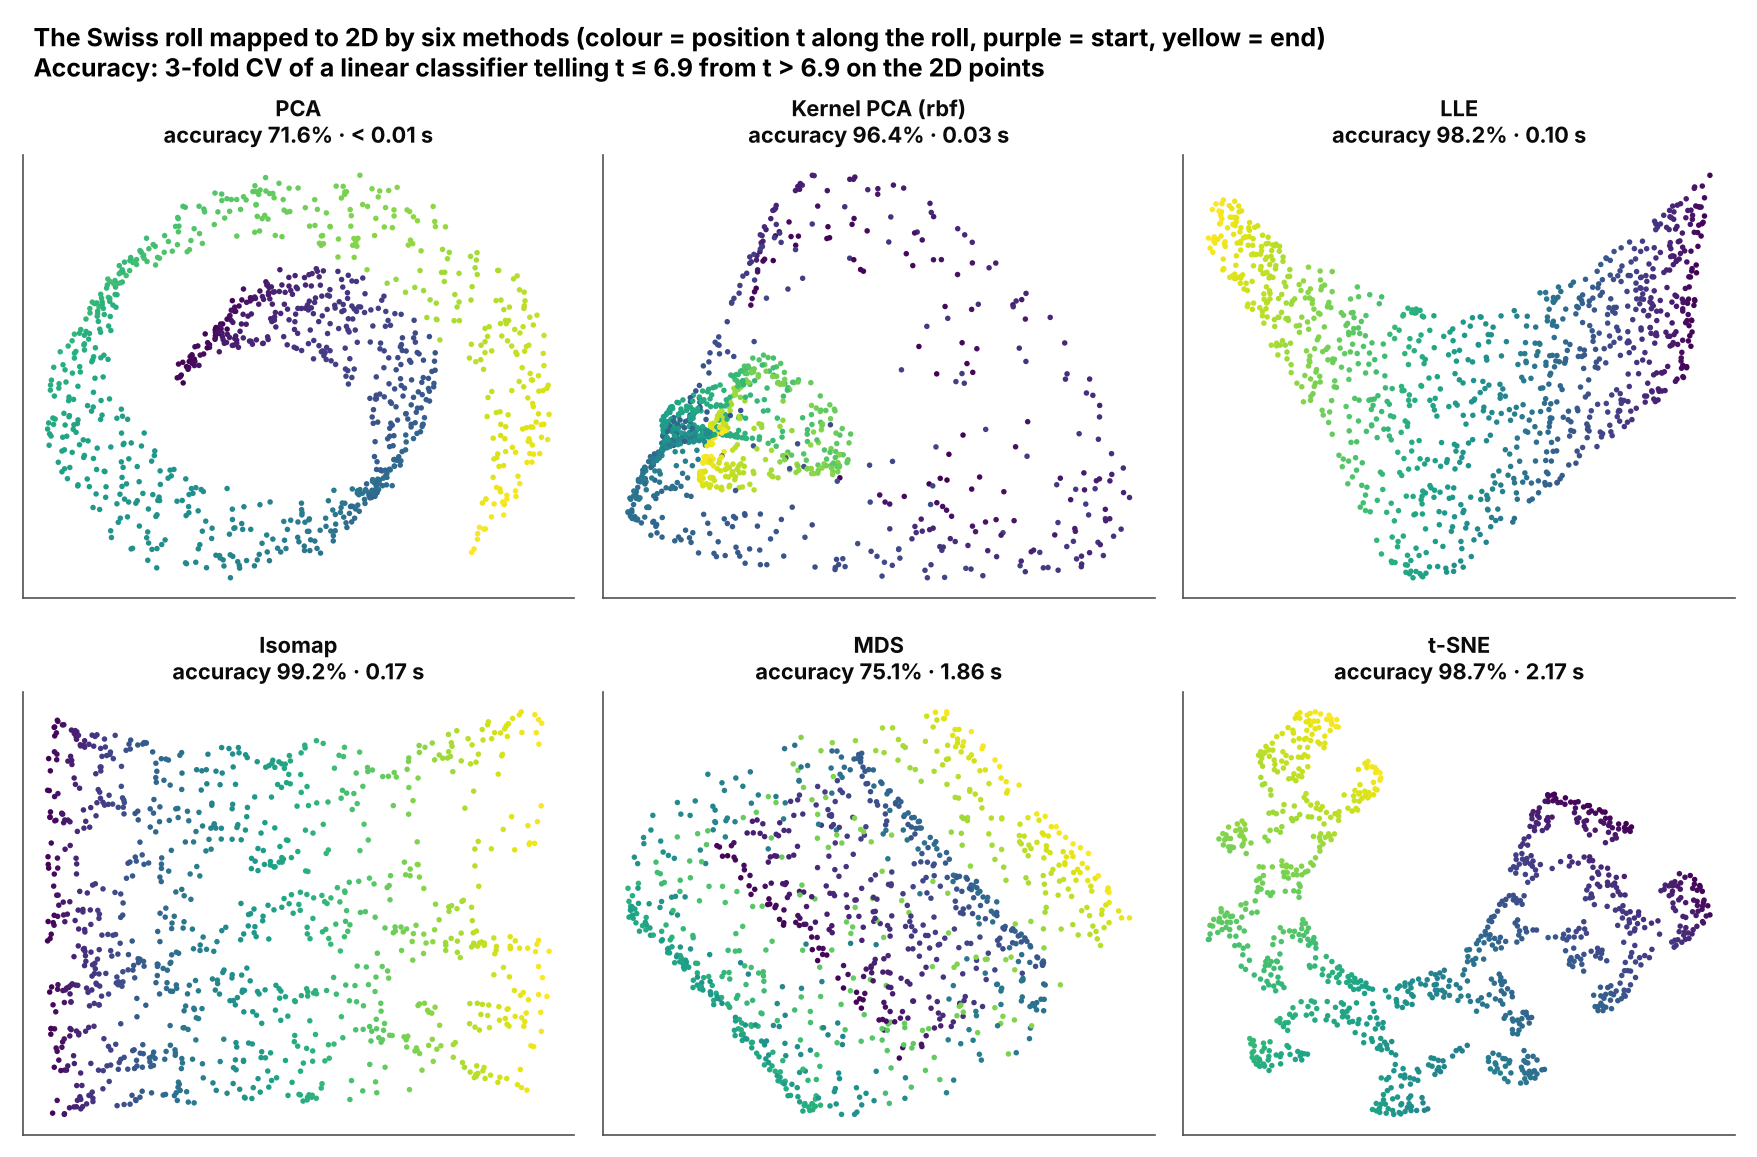

In [8]:
from dimred_mlops import plots
best_sig = c.grid[c.grid.kernel == "sigmoid"].sort_values("cv_accuracy").iloc[-1]
plots.swiss_roll_kpca(c.roll, FIG / "c_swiss_roll_kpca.png", c.metrics["best_gamma"], float(best_sig.gamma))
plots.kpca_selection(c.grid, c.preimage, c.metrics["best_gamma"], c.metrics["preimage_best_gamma"],
                     c.params["best_kernel"], c.params["preimage_best_kernel"], FIG / "c_kpca_selection.png")
plots.manifold_methods(c.embeddings, c.roll["t"], c.methods, FIG / "c_manifold_methods.png")
for f in ["c_swiss_roll_kpca", "c_kpca_selection", "c_manifold_methods"]:
    display(Image(str(FIG / f"{f}.png"), width=900))

## Takeaways
* The supervised grid search picks the RBF kernel with γ ≈ 0.04, close to the book's 0.0433, and reaches about 96% held-out accuracy. That is far above Logistic Regression on the raw 3D points or on linear PCA.
* The unsupervised rule (lowest pre-image error) picks a *sigmoid* kernel with a small gamma. tanh(gamma x.x' + 1) is then almost an affine function of x.x', so this kernel behaves like linear PCA: it rebuilds the inputs well but does not unroll the roll, and its accuracy is close to linear PCA's. The two rules answer different questions, so check what the reduction is for before choosing one.
* About 7 of the 20 settings are within one standard deviation of the best CV accuracy, so the exact gamma is not significant.
* Isomap and t-SNE separate the two halves of the roll best. LLE unrolls it, with the position along the roll on one axis, but squeezes it unevenly (p. 232).